# 03 数据质量、清洗实验与标签影响分析

这个 Notebook 回答一个核心问题：赛题说明提到的“传感器异常、信号缺失、航速离群点”等问题，我们到底解决了吗？如果解决，清洗对 A/B 训练标签和回测有没有实质影响？

结论先行：

- 原始 AIS 中确实存在大量轨迹跳点、重复 `mmsi-time`、heading/rot 异常。
- 但在官方“小时级聚合”口径下，简单清洗对 A/B 标签影响非常小。
- 因此，线上成绩和正确答案差距大，主要不能指望靠简单删异常点解决；更可能来自验证期分布变化、预测方法过弱、每日/分时段尺度不准。

## 0. 路径与实验开关

本 Notebook 默认读取已经由 `src/data_quality_experiments.py` 生成的最新清洗实验目录。若要重新跑全量实验，把 `RUN_EXPERIMENT = True`。

In [1]:
from pathlib import Path
import subprocess
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

ROOT = Path.cwd()
if not (ROOT / "src" / "data_quality_experiments.py").exists():
    ROOT = ROOT.parent

RUN_EXPERIMENT = False

if RUN_EXPERIMENT:
    subprocess.run([sys.executable, str(ROOT / "src" / "data_quality_experiments.py")], cwd=ROOT, check=True)

quality_runs = sorted((ROOT / "outputs").glob("*_quality_cleaning"))
if not quality_runs:
    raise FileNotFoundError("找不到 *_quality_cleaning 输出目录，请先运行 src/data_quality_experiments.py")
RUN_DIR = quality_runs[-1]
print("ROOT:", ROOT)
print("RUN_DIR:", RUN_DIR)

ROOT: C:\Users\mandy\hl_Documents\2026CTS
RUN_DIR: C:\Users\mandy\hl_Documents\2026CTS\outputs\20260709_112307_quality_cleaning


## 1. 原始数据质量问题量化

这里先看异常不是“有没有”，而是“有多少”。特别注意：`SOG` 字段本身离群并不多，但相邻点反算速度异常很多，说明主要问题是坐标跳点、信号断裂或时空不连续。

,metric,value
0,rows,2039846
1,unique_mmsi,109
2,missing_true_heading,354
3,missing_rot,11542
4,true_heading_invalid,151898
5,cog_invalid,278
6,sog_gt_15,1388
7,sog_gt_30,269
8,outside_30km,71020
9,duplicate_mmsi_time_rows,20472


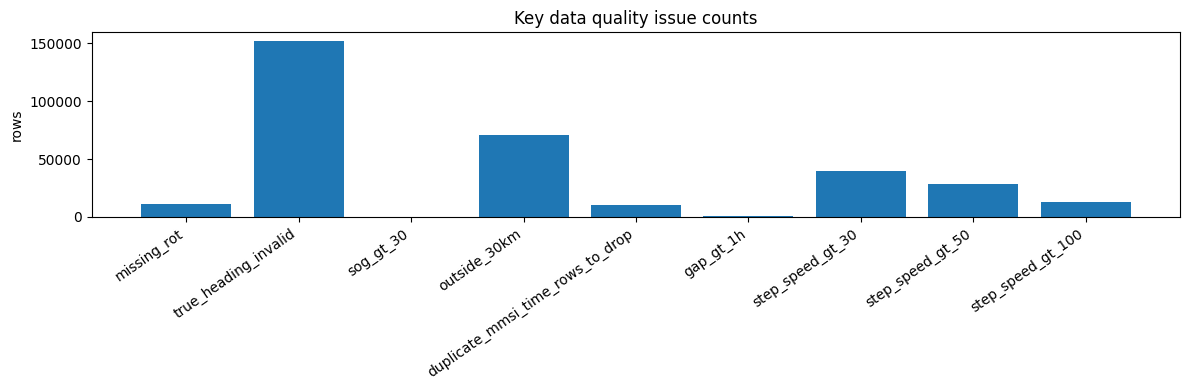

In [2]:
diag = pd.read_csv(RUN_DIR / "quality_diagnostics.csv")
display(diag)

diag_plot = diag[diag["metric"].isin([
    "sog_gt_30", "outside_30km", "duplicate_mmsi_time_rows_to_drop", "gap_gt_1h",
    "step_speed_gt_30", "step_speed_gt_50", "step_speed_gt_100", "true_heading_invalid", "missing_rot"
])].copy()
plt.figure(figsize=(12, 4))
plt.bar(diag_plot["metric"], diag_plot["value"])
plt.xticks(rotation=35, ha="right")
plt.title("Key data quality issue counts")
plt.ylabel("rows")
plt.tight_layout()
plt.show()

## 2. 清洗版本定义

本轮不是直接假设某种清洗一定正确，而是比较多个版本：

- `raw`：不清洗。
- `dedup_mmsi_time`：同船同秒重复，只保留第一条。
- `drop_step_gt_100/50/30`：删除相邻点反算速度超过阈值的当前点。
- `dedup_drop_step_gt_50`：去重 + 删除 `>50 kn` 跳点。
- `dedup_drop_step_gt_50_sog_le_30`：再额外删除 `SOG > 30` 点。

注意：这不是最终清洗方案，只是评估“这些异常对官方小时标签影响多大”。

,version,rows,removed_rows,removed_ratio,unique_mmsi,outside_rows,active_sog_2_10_rows
0,raw,2039846,0,0.000000,109,71020,444268
1,dedup_mmsi_time,2029603,10243,0.005021,109,70713,441317
2,drop_step_gt_100,2027303,12543,0.006149,109,70170,437164
3,drop_step_gt_50,2011541,28305,0.013876,109,69018,427875
4,drop_step_gt_30,1999864,39982,0.019600,109,68257,419774
5,dedup_drop_step_gt_50,2001298,38548,0.018898,109,68711,424924
6,dedup_drop_step_gt_50_sog_le_30,2001033,38813,0.019027,107,68710,424924


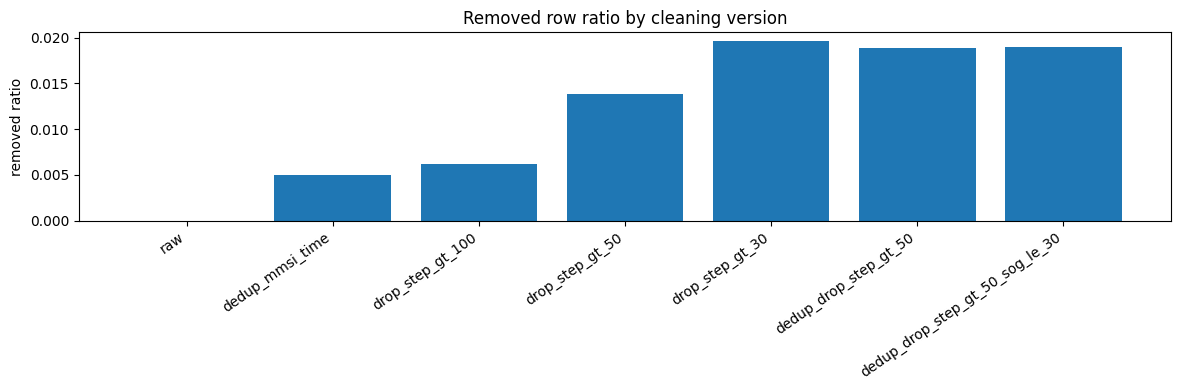

In [3]:
version_summary = pd.read_csv(RUN_DIR / "clean_version_summary.csv")
display(version_summary)

plt.figure(figsize=(12, 4))
plt.bar(version_summary["version"], version_summary["removed_ratio"])
plt.xticks(rotation=35, ha="right")
plt.title("Removed row ratio by cleaning version")
plt.ylabel("removed ratio")
plt.tight_layout()
plt.show()

## 3. 清洗对 A/B 标签的影响

这里比较每个清洗版本生成的 A/B 标签，与 raw 官方口径标签之间的差异。若清洗真正改变任务信号，`changed_rows`、`sum_abs_delta`、`sse_between` 应该明显变大。

,version,label,rows,changed_rows,sum_raw,sum_clean,sum_delta,sum_abs_delta,sse_between,max_abs_delta
0,raw,A,1728,0,6593.0,6593.0,0.0,0.0,0.0,0.0
1,raw,B,3456,0,1910.0,1910.0,0.0,0.0,0.0,0.0
2,dedup_mmsi_time,A,1728,3,6593.0,6590.0,-3.0,3.0,3.0,1.0
3,dedup_mmsi_time,B,3456,9,1910.0,1911.0,1.0,9.0,9.0,1.0
4,drop_step_gt_100,A,1728,5,6593.0,6588.0,-5.0,5.0,5.0,1.0
5,drop_step_gt_100,B,3456,10,1910.0,1908.0,-2.0,10.0,10.0,1.0
6,drop_step_gt_50,A,1728,9,6593.0,6584.0,-9.0,9.0,9.0,1.0
7,drop_step_gt_50,B,3456,22,1910.0,1912.0,2.0,22.0,22.0,1.0
8,drop_step_gt_30,A,1728,17,6593.0,6576.0,-17.0,17.0,17.0,1.0
9,drop_step_gt_30,B,3456,25,1910.0,1911.0,1.0,25.0,25.0,1.0


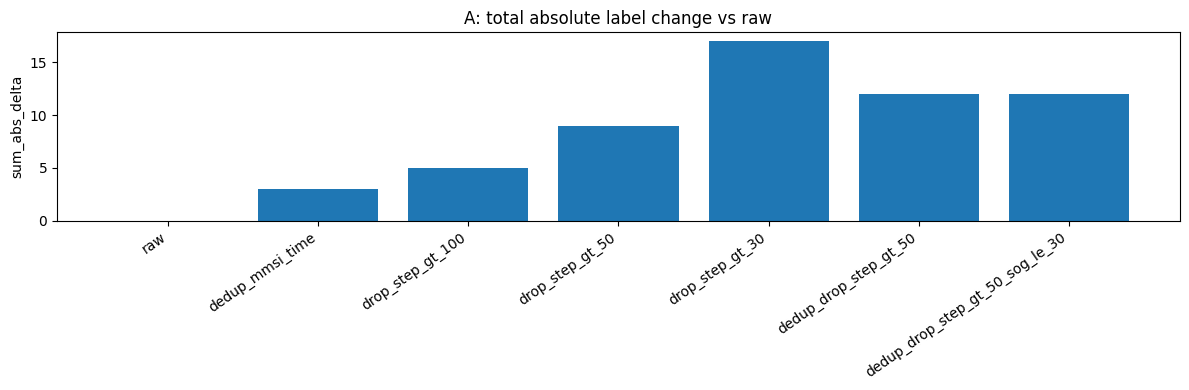

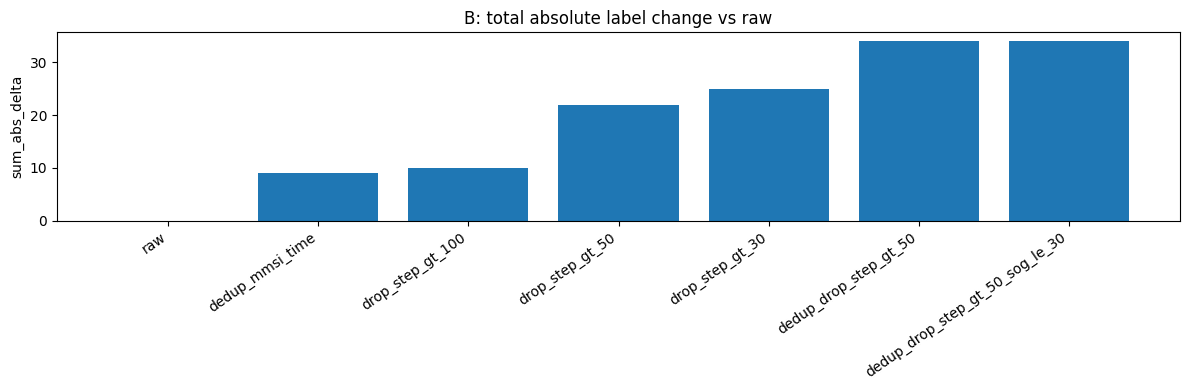

In [4]:
label_diff = pd.read_csv(RUN_DIR / "label_diff_summary.csv")
display(label_diff)

for label in ["A", "B"]:
    sub = label_diff[label_diff["label"] == label]
    plt.figure(figsize=(12, 4))
    plt.bar(sub["version"], sub["sum_abs_delta"])
    plt.xticks(rotation=35, ha="right")
    plt.title(f"{label}: total absolute label change vs raw")
    plt.ylabel("sum_abs_delta")
    plt.tight_layout()
    plt.show()

### 关键观察

即使删除了 28,305 条 `>50 kn` 跳点，A 标签只变化 9 个计数，B 标签只变化 22 个计数。严格组合清洗也只是 A 变化 12、B 变化 34。

这说明官方标签的小时聚合规则相当“抗噪”：大部分点异常不会改变小时级船数或代表圈层。

## 4. 哪些标签行变化最大？

变化最大也只有 1，说明这些清洗没有造成大规模标签重写。

In [5]:
top_changes = pd.read_csv(RUN_DIR / "top_label_changes.csv", parse_dates=["hour"])
for label in ["A", "B"]:
    print("\n", label)
    cols = [col for col in ["version", "label", "hour", "region", "source_region", "target_region", "y_raw", "y_clean", "delta", "abs_delta"] if col in top_changes.columns]
    display(top_changes[top_changes["label"] == label][cols].head(20))


 A


,version,label,hour,region,source_region,target_region,y_raw,y_clean,delta,abs_delta
0,dedup_mmsi_time,A,2018-01-10 23:00:00,near,NaN,NaN,5,4,-1,1
1,dedup_mmsi_time,A,2018-01-15 12:00:00,near,NaN,NaN,4,3,-1,1
2,dedup_mmsi_time,A,2018-01-23 20:00:00,near,NaN,NaN,11,10,-1,1
3,dedup_mmsi_time,A,2018-01-24 14:00:00,core,NaN,NaN,14,14,0,0
4,dedup_mmsi_time,A,2018-01-24 14:00:00,near,NaN,NaN,5,5,0,0
5,dedup_mmsi_time,A,2018-01-24 14:00:00,outer,NaN,NaN,2,2,0,0
6,dedup_mmsi_time,A,2018-01-24 15:00:00,core,NaN,NaN,16,16,0,0
7,dedup_mmsi_time,A,2018-01-24 15:00:00,near,NaN,NaN,13,13,0,0
8,dedup_mmsi_time,A,2018-01-24 15:00:00,outer,NaN,NaN,2,2,0,0
9,dedup_mmsi_time,A,2018-01-24 16:00:00,core,NaN,NaN,14,14,0,0



 B


,version,label,hour,region,source_region,target_region,y_raw,y_clean,delta,abs_delta
50,dedup_mmsi_time,B,2018-01-16 15:00:00,NaN,outer,core,1,0,-1,1
51,dedup_mmsi_time,B,2018-01-16 15:00:00,NaN,outer,near,0,1,1,1
52,dedup_mmsi_time,B,2018-01-16 16:00:00,NaN,core,near,1,0,-1,1
53,dedup_mmsi_time,B,2018-01-19 14:00:00,NaN,core,near,1,2,1,1
54,dedup_mmsi_time,B,2018-01-19 15:00:00,NaN,core,outer,1,0,-1,1
55,dedup_mmsi_time,B,2018-01-19 15:00:00,NaN,near,outer,0,1,1,1
56,dedup_mmsi_time,B,2018-01-20 13:00:00,NaN,outer,core,0,1,1,1
57,dedup_mmsi_time,B,2018-01-20 14:00:00,NaN,core,near,1,2,1,1
58,dedup_mmsi_time,B,2018-01-20 14:00:00,NaN,outer,near,2,1,-1,1
59,dedup_mmsi_time,B,2018-01-24 14:00:00,NaN,outer,near,1,1,0,0


## 5. 跳点集中在哪些船？

大量 `>50 kn` 跳点集中在一批船上。但这些船是否应该删掉，需要非常谨慎，因为它们可能同时也贡献了真实作业信号。

,mmsi,rows
0,1045,2323
1,1129,1964
2,3080,1660
3,1119,1526
4,1051,1460
5,3077,1457
6,2519,1375
7,1066,1317
8,1050,1286
9,1128,1184


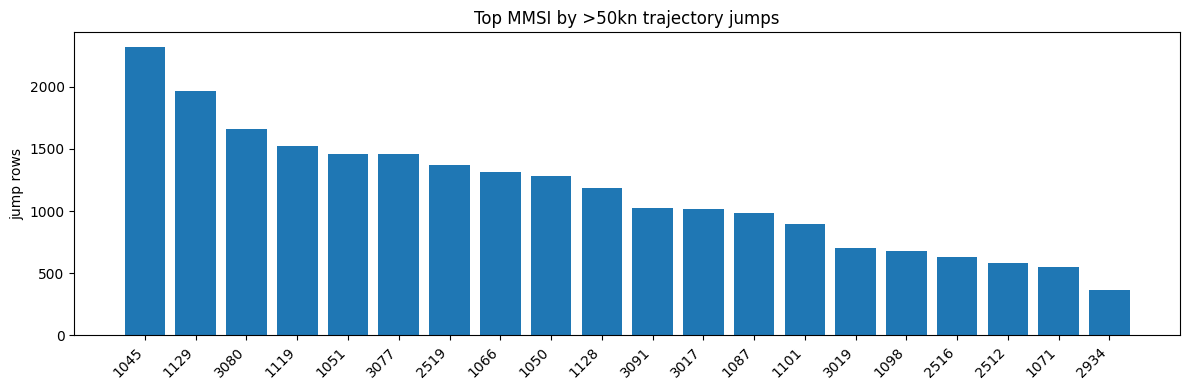

In [6]:
top_mmsi = pd.read_csv(RUN_DIR / "jump_gt_50_top_mmsi.csv")
display(top_mmsi.head(30))

plt.figure(figsize=(12, 4))
plt.bar(top_mmsi.head(20)["mmsi"].astype(str), top_mmsi.head(20)["rows"])
plt.xticks(rotation=45, ha="right")
plt.title("Top MMSI by >50kn trajectory jumps")
plt.ylabel("jump rows")
plt.tight_layout()
plt.show()

## 6. 清洗标签用于训练是否改善回测？

为了进一步判断清洗是否有用，我们做一个更贴近评测的实验：

- 训练阶段使用某个清洗版本的标签。
- 验证阶段仍然用 raw 官方口径标签作为真值。
- 模型只用简单 `hour_mean`，避免模型复杂度干扰。

如果清洗真的让训练标签更接近未来真实规律，这个回测应该明显变好。

,version,mean_score,mean_sse_a,mean_sse_b,max_score
0,drop_step_gt_50,8372.310923,5735.018085,879.097612,9073.36
1,drop_step_gt_100,8373.084717,5734.322537,879.587393,9079.17
2,drop_step_gt_30,8373.737416,5735.375029,879.454129,9071.21
3,raw,8373.791038,5734.117059,879.891326,9080.94
4,dedup_drop_step_gt_50,8374.802295,5735.897105,879.635063,9070.29
5,dedup_drop_step_gt_50_sog_le_30,8374.802295,5735.897105,879.635063,9070.29
6,dedup_mmsi_time,8376.939366,5734.996078,880.647762,9077.87


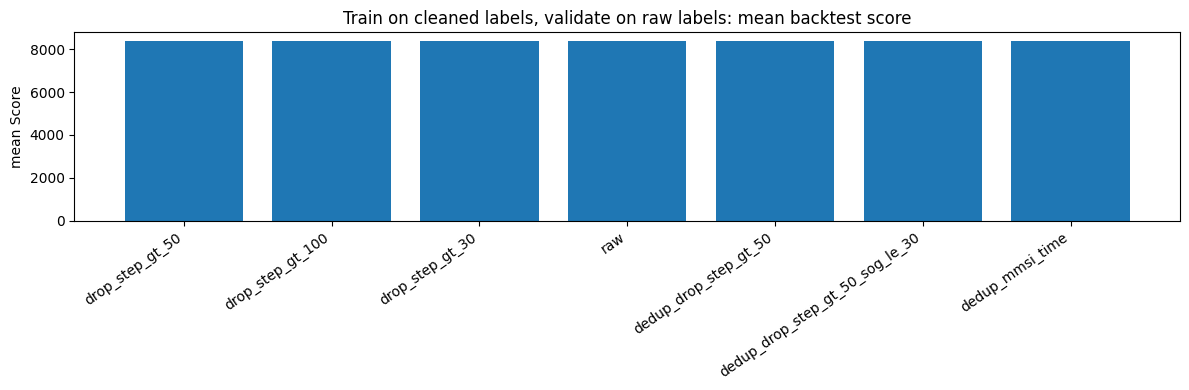

In [7]:
cv = pd.read_csv(RUN_DIR / "clean_train_raw_valid_backtest_summary.csv")
display(cv)

plt.figure(figsize=(12, 4))
plt.bar(cv["version"], cv["mean_score"])
plt.xticks(rotation=35, ha="right")
plt.title("Train on cleaned labels, validate on raw labels: mean backtest score")
plt.ylabel("mean Score")
plt.tight_layout()
plt.show()

### 回测结论

`drop_step_gt_50` 的均分从 raw 的 `8373.79` 变成 `8372.31`，只改善约 `1.48`，几乎可以忽略。

所以：

- 简单异常点删除不是线上分数差距的主因。
- 继续在点级清洗上大幅调参，收益很可能很低。
- 更应该优化时间序列预测本身：每日尺度、小时形状、验证期每日船数约束、A/B 分区域分方向建模。

## 7. 本阶段结论：到底解决了什么？

已解决/已量化：

- 明确量化了缺失、重复、离群、跳点、断点规模。
- 实现了多档清洗规则。
- 生成了每个清洗版本的 A/B 标签。
- 证明简单清洗对官方小时标签影响很小。
- 证明用清洗标签训练对 raw 口径回测几乎没有改善。

没有解决/不建议盲目做：

- 不建议直接删除大量船或大量跳点作为最终方案。
- 不建议把 `heading/rot` 异常作为标签过滤条件，因为官方 A/B 口径不依赖它们。
- 不建议认为线上差距主要来自传感器异常。

下一步方向：

1. A 题重点改预测尺度和小时形状，而不是点级清洗。
2. B 题继续保持近期小时迁移模式，但可以按方向单独调。
3. 用线上反馈校准 A/B 倍率时，要先判断 A 是整体偏高还是偏低；目前 `A085` 变差，说明 A 不该下调。
4. 如果继续做清洗，只把 `drop_step_gt_50` 作为一个弱 ensemble 版本，而不是主方案。